In [1]:
import json
import math
import random
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.autograd import Function
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

Device: cuda
GPU   : NVIDIA GeForce RTX 4060


In [2]:
# =========================
# 2) Konfigurasi utama
# =========================
CFG = {
'model_name': 'indolem/indobert-base-uncased',
'source_csv': '../../datasets/telemedicine_preprocessed/train.csv',
'target_csv': '../../datasets/lazada_train_preprocessed.csv',
'eval_csv': '../../datasets/lazada_test_preprocessed.csv',  # boleh None
'output_dir': 'outputs',

'epochs': 3,
'batch_size': 32,
'max_length': 128,
'learning_rate': 1e-5,
'weight_decay': 0.02,
'warmup_ratio': 0.1,
'dropout': 0.2,
'domain_loss_weight': 0.1,
'max_grad_norm': 1.0,
'seed': 42,

# Adapter config: bottleneck layer untuk parameter-efficient tuning
# Adapter diletakkan di antara encoder -> task heads agar encoder tetap stabil
# tapi representasi bisa diadaptasi untuk klasifikasi sentimen dan domain alignment
'use_adapters': True,
'adapter_dim': 16,
}

for k in ['source_csv', 'target_csv']:
    print(k, '=>', CFG[k], '| exists:', Path(CFG[k]).exists())
print('eval_csv =>', CFG['eval_csv'], '| exists:', Path(CFG['eval_csv']).exists() if CFG['eval_csv'] else False)
print('use_adapters =>', CFG['use_adapters'], '| adapter_dim =>', CFG['adapter_dim'])

source_csv => ../../datasets/telemedicine_preprocessed/train.csv | exists: True
target_csv => ../../datasets/lazada_train_preprocessed.csv | exists: True
eval_csv => ../../datasets/lazada_test_preprocessed.csv | exists: True
use_adapters => True | adapter_dim => 16


In [3]:
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL = {0: 'negative', 1: 'positive'}

def _resolve_text_column(df: pd.DataFrame) -> str:
    for col in ['content', 'reviewContent', 'text', 'review']:
        if col in df.columns:
            return col
    raise ValueError(f'Cannot find text column. Available columns: {df.columns.tolist()}')

def _resolve_label_column(df: pd.DataFrame) -> str:
    for col in ['label', 'sentiment', 'target']:
        if col in df.columns:
            return col
    raise ValueError(f'Cannot find label column. Available columns: {df.columns.tolist()}')

def _normalize_labels(series: pd.Series) -> pd.Series:
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.replace({'neg': 'negative', 'pos': 'positive'})

def clean_dataframe(df: pd.DataFrame, text_col: str, label_col: Optional[str] = None) -> pd.DataFrame:
    use_cols = [text_col] + ([label_col] if label_col else [])
    out = df[use_cols].copy()
    out = out.dropna(subset=[text_col])
    out[text_col] = out[text_col].astype(str).str.strip()
    out = out[out[text_col] != '']

    if label_col:
        out = out.dropna(subset=[label_col])
        out[label_col] = _normalize_labels(out[label_col])
        out = out[out[label_col].isin(LABEL2ID)]

    return out.reset_index(drop=True)

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128, labels=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )

        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }

        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

def make_loaders(
    tokenizer,
    source_path: Path,
    target_path: Path,
    eval_path: Optional[Path],
    batch_size: int,
    max_length: int,
    seed: int,
) -> Tuple[DataLoader, DataLoader, DataLoader, Optional[DataLoader], dict]:
    source_df = pd.read_csv(source_path)
    source_text_col = _resolve_text_column(source_df)
    source_label_col = _resolve_label_column(source_df)
    source_df = clean_dataframe(source_df, source_text_col, source_label_col)
    source_df['label_id'] = source_df[source_label_col].map(LABEL2ID)

    train_df, val_df = train_test_split(
        source_df,
        test_size=0.1,
        random_state=seed,
        stratify=source_df['label_id'],
    )

    target_df = pd.read_csv(target_path)
    target_text_col = _resolve_text_column(target_df)
    target_df = clean_dataframe(target_df, target_text_col)

    source_train_ds = TextDataset(
        texts=train_df[source_text_col].tolist(),
        labels=train_df['label_id'].tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )
    source_val_ds = TextDataset(
        texts=val_df[source_text_col].tolist(),
        labels=val_df['label_id'].tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )
    target_train_ds = TextDataset(
        texts=target_df[target_text_col].tolist(),
        labels=None,
        tokenizer=tokenizer,
        max_length=max_length,
    )

    source_train_loader = DataLoader(source_train_ds, batch_size=batch_size, shuffle=True)
    source_val_loader = DataLoader(source_val_ds, batch_size=batch_size, shuffle=False)
    target_train_loader = DataLoader(target_train_ds, batch_size=batch_size, shuffle=True)

    eval_loader = None
    eval_samples = 0

    if eval_path is not None and eval_path.exists():
        eval_df = pd.read_csv(eval_path)
        eval_text_col = _resolve_text_column(eval_df)
        eval_label_col = _resolve_label_column(eval_df)

        if 'origin' in eval_df.columns:
            origin = eval_df['origin'].astype(str).str.lower()
            target_only = eval_df[origin == 'target']
            if len(target_only) > 0:
                eval_df = target_only

        eval_df = clean_dataframe(eval_df, eval_text_col, eval_label_col)
        eval_df['label_id'] = eval_df[eval_label_col].map(LABEL2ID)

        eval_ds = TextDataset(
            texts=eval_df[eval_text_col].tolist(),
            labels=eval_df['label_id'].tolist(),
            tokenizer=tokenizer,
            max_length=max_length,
        )
        eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)
        eval_samples = len(eval_ds)

    stats = {
        'source_train': len(source_train_ds),
        'source_val': len(source_val_ds),
        'target_train': len(target_train_ds),
        'target_eval': eval_samples,
    }

    return source_train_loader, source_val_loader, target_train_loader, eval_loader, stats

In [4]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, inputs, alpha):
        ctx.alpha = alpha
        return inputs.view_as(inputs)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

class GradientReversalLayer(nn.Module):
    def forward(self, inputs, alpha=1.0):
        return GradientReversalFunction.apply(inputs, alpha)

class PfeifferAdapter(nn.Module):
    def __init__(self, hidden_size: int, adapter_dim: int, dropout: float = 0.1):
        super().__init__()
        self.down = nn.Linear(hidden_size, adapter_dim)
        self.act = nn.GELU()
        self.up = nn.Linear(adapter_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Residual adapter: mempertahankan fitur asli sambil menambahkan delta kecil
        # yang mudah dipelajari. Ini membantu fine-tuning lebih stabil dan efisien.
        return x + self.dropout(self.up(self.act(self.down(x))))

class DANNModel(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels: int = 2,
        dropout: float = 0.1,
        use_adapters: bool = True,
        adapter_dim: int = 128,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        print("Hidden Size: ", hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.use_adapters = use_adapters

        # Adapter placement (exact location):
        # 1) label_adapter dipakai setelah encoder feature dan sebelum label classifier
        #    supaya representasi lebih fokus ke sentiment task.
        # 2) domain_adapter dipakai sebelum GRL + domain classifier
        #    supaya representasi domain dapat disesuaikan untuk domain confusion.
        # Jika use_adapters=False, model kembali ke arsitektur DANN standar.
        if self.use_adapters:
            self.label_adapter = PfeifferAdapter(hidden_size, adapter_dim, dropout=dropout)
            self.domain_adapter = PfeifferAdapter(hidden_size, adapter_dim, dropout=dropout)
        else:
            self.label_adapter = nn.Identity()
            self.domain_adapter = nn.Identity()

        self.label_classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, num_labels),
        )

        self.grl = GradientReversalLayer()

        self.domain_classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2),
        )

    def extract_features(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0]

    def forward(self, input_ids, attention_mask, alpha=1.0):
        features = self.extract_features(input_ids, attention_mask)
        features = self.dropout(features)

        # Branch 1: Sentiment classification adapter path
        label_features = self.label_adapter(features)
        class_logits = self.label_classifier(label_features)

        # Branch 2: Domain classifier adapter path
        domain_features = self.domain_adapter(features)
        reversed_features = self.grl(domain_features, alpha=alpha)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits

In [5]:
@torch.no_grad()
def evaluate_label_head(model, dataloader, device):
    model.eval()

    all_preds, all_labels = [], []
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        class_logits, _ = model(input_ids, attention_mask, alpha=0.0)
        loss = loss_fn(class_logits, labels)

        total_loss += loss.item()
        all_preds.extend(torch.argmax(class_logits, dim=1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / max(1, len(dataloader))
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    return {
        'loss': avg_loss,
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'preds': all_preds,
        'labels': all_labels,
    }

def _pretty_metrics(title: str, metrics: dict):
    print(title)
    print('=' * len(title))
    print(
        f"loss={metrics['loss']:.4f} acc={metrics['acc']:.4f} "
        f"precision={metrics['precision']:.4f} recall={metrics['recall']:.4f} f1={metrics['f1']:.4f}"
    )


def _metrics_dict(metrics: dict) -> dict:
    return {
        'loss': float(metrics['loss']),
        'accuracy': float(metrics['acc']),
        'precision': float(metrics['precision']),
        'recall': float(metrics['recall']),
        'f1': float(metrics['f1']),
    }

def train_dann(cfg: dict):
    set_seed(cfg['seed'])

    source_path = Path(cfg['source_csv'])
    target_path = Path(cfg['target_csv'])
    eval_path = Path(cfg['eval_csv']) if cfg.get('eval_csv') else None

    tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])

    source_train_loader, source_val_loader, target_train_loader, target_eval_loader, stats = make_loaders(
        tokenizer=tokenizer,
        source_path=source_path,
        target_path=target_path,
        eval_path=eval_path,
        batch_size=cfg['batch_size'],
        max_length=cfg['max_length'],
        seed=cfg['seed'],
    )

    print('Dataset summary:', stats)

    model = DANNModel(
        model_name=cfg['model_name'],
        num_labels=2,
        dropout=cfg['dropout'],
        use_adapters=cfg.get('use_adapters', True),
        adapter_dim=cfg.get('adapter_dim', 128),
    ).to(device)

    class_loss_fn = nn.CrossEntropyLoss()
    domain_loss_fn = nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=cfg['learning_rate'], weight_decay=cfg['weight_decay'])

    steps_per_epoch = min(len(source_train_loader), len(target_train_loader))
    total_steps = cfg['epochs'] * steps_per_epoch
    warmup_steps = int(cfg['warmup_ratio'] * total_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    best_val_f1 = -1.0
    best_dir = Path(cfg['output_dir']) / 'best'
    best_dir.mkdir(parents=True, exist_ok=True)

    global_step = 0
    best_val_metrics = None

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()

        running_total = 0.0
        running_cls = 0.0
        running_domain = 0.0

        source_iter = iter(source_train_loader)
        target_iter = iter(target_train_loader)

        progress = tqdm(range(steps_per_epoch), desc=f'Epoch {epoch}/{cfg["epochs"]}')
        for step_idx in progress:
            source_batch = next(source_iter)
            target_batch = next(target_iter)

            p = float(global_step) / max(1, total_steps - 1)
            alpha = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0

            source_input_ids = source_batch['input_ids'].to(device)
            source_attention_mask = source_batch['attention_mask'].to(device)
            source_labels = source_batch['labels'].to(device)

            target_input_ids = target_batch['input_ids'].to(device)
            target_attention_mask = target_batch['attention_mask'].to(device)

            class_logits, source_domain_logits = model(source_input_ids, source_attention_mask, alpha=alpha)
            _, target_domain_logits = model(target_input_ids, target_attention_mask, alpha=alpha)

            cls_loss = class_loss_fn(class_logits, source_labels)

            source_domain_labels = torch.zeros(source_domain_logits.size(0), dtype=torch.long, device=device)
            target_domain_labels = torch.ones(target_domain_logits.size(0), dtype=torch.long, device=device)

            domain_source_loss = domain_loss_fn(source_domain_logits, source_domain_labels)
            domain_target_loss = domain_loss_fn(target_domain_logits, target_domain_labels)
            domain_loss = 0.5 * (domain_source_loss + domain_target_loss)

            total_loss = cls_loss + cfg['domain_loss_weight'] * domain_loss

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['max_grad_norm'])
            optimizer.step()
            scheduler.step()

            running_total += total_loss.item()
            running_cls += cls_loss.item()
            running_domain += domain_loss.item()
            global_step += 1

            seen = step_idx + 1
            progress.set_postfix(
                total=f'{running_total/seen:.4f}',
                cls=f'{running_cls/seen:.4f}',
                dom=f'{running_domain/seen:.4f}',
                alpha=f'{alpha:.3f}',
            )

        val_metrics = evaluate_label_head(model, source_val_loader, device)
        print(
            f'Epoch {epoch} | val_loss={val_metrics["loss"]:.4f} val_acc={val_metrics["acc"]:.4f} '
            f'val_precision={val_metrics["precision"]:.4f} val_recall={val_metrics["recall"]:.4f} val_f1={val_metrics["f1"]:.4f}'
        )

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_val_metrics = val_metrics
            model.encoder.save_pretrained(best_dir)
            tokenizer.save_pretrained(best_dir)
            torch.save(
                {
                    'label_classifier': model.label_classifier.state_dict(),
                    'domain_classifier': model.domain_classifier.state_dict(),
                    'label_adapter': model.label_adapter.state_dict(),
                    'domain_adapter': model.domain_adapter.state_dict(),
                    'args': cfg,
                },
                best_dir / 'dann_heads.pt',
            )
            print('  Saved new best model to:', best_dir)

    print(f'Training complete. Best source-val F1: {best_val_f1:.4f}')

    # Reload the actual best checkpoint and evaluate from there
    print('\nReloading best checkpoint for final evaluation...')
    best_model = DANNModel(
        model_name=str(best_dir),
        num_labels=2,
        dropout=cfg['dropout'],
        use_adapters=cfg.get('use_adapters', True),
        adapter_dim=cfg.get('adapter_dim', 128),
    ).to(device)
    heads = torch.load(best_dir / 'dann_heads.pt', map_location=device)
    best_model.label_classifier.load_state_dict(heads['label_classifier'])
    best_model.domain_classifier.load_state_dict(heads['domain_classifier'])
    if 'label_adapter' in heads and 'domain_adapter' in heads:
        best_model.label_adapter.load_state_dict(heads['label_adapter'])
        best_model.domain_adapter.load_state_dict(heads['domain_adapter'])

    source_best_metrics = evaluate_label_head(best_model, source_val_loader, device)
    _pretty_metrics('Source Evaluation (best checkpoint)', source_best_metrics)

    comparison_metrics = {
        'framework': 'dann',
        'split': 'source_val',
        'best_checkpoint': str(best_dir),
        'source_val': _metrics_dict(source_best_metrics),
    }

    if target_eval_loader is not None:
        print('\nEvaluating best checkpoint on target labeled set...')
        target_best_metrics = evaluate_label_head(best_model, target_eval_loader, device)
        _pretty_metrics('Target Evaluation (best checkpoint)', target_best_metrics)
        print('\nClassification report (target eval):')
        print(classification_report(target_best_metrics['labels'], target_best_metrics['preds'], target_names=[ID2LABEL[0], ID2LABEL[1]], digits=4))

        comparison_metrics['target_eval'] = _metrics_dict(target_best_metrics)
        comparison_metrics['primary_split'] = 'target_eval'
        comparison_metrics['loss'] = comparison_metrics['target_eval']['loss']
        comparison_metrics['accuracy'] = comparison_metrics['target_eval']['accuracy']
        comparison_metrics['precision'] = comparison_metrics['target_eval']['precision']
        comparison_metrics['recall'] = comparison_metrics['target_eval']['recall']
        comparison_metrics['f1'] = comparison_metrics['target_eval']['f1']
    else:
        comparison_metrics['primary_split'] = 'source_val'
        comparison_metrics['loss'] = comparison_metrics['source_val']['loss']
        comparison_metrics['accuracy'] = comparison_metrics['source_val']['accuracy']
        comparison_metrics['precision'] = comparison_metrics['source_val']['precision']
        comparison_metrics['recall'] = comparison_metrics['source_val']['recall']
        comparison_metrics['f1'] = comparison_metrics['source_val']['f1']

    print('\nSource Evaluation')
    print('===========================')
    print(comparison_metrics['source_val'])

    if 'target_eval' in comparison_metrics:
        print('\nTarget Evaluation')
        print('===========================')
        print(comparison_metrics['target_eval'])

    comparison_path = Path(cfg['output_dir']) / 'comparison_metrics.json'
    comparison_path.parent.mkdir(parents=True, exist_ok=True)
    with open(comparison_path, 'w', encoding='utf-8') as f:
        json.dump(comparison_metrics, f, indent=2)

    print('Saved comparison metrics to:', comparison_path)
    return best_dir

best_model_dir = train_dann(CFG)
print('Best checkpoint dir:', best_model_dir)

Dataset summary: {'source_train': 6026, 'source_val': 670, 'target_train': 8142, 'target_eval': 2042}
Hidden Size:  768


Epoch 1/3:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 1 | val_loss=0.2659 val_acc=0.8940 val_precision=0.8994 val_recall=0.8940 val_f1=0.8937
  Saved new best model to: outputs\best


Epoch 2/3:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 2 | val_loss=0.2066 val_acc=0.9343 val_precision=0.9346 val_recall=0.9343 val_f1=0.9343
  Saved new best model to: outputs\best


Epoch 3/3:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 3 | val_loss=0.2004 val_acc=0.9343 val_precision=0.9349 val_recall=0.9343 val_f1=0.9343
Training complete. Best source-val F1: 0.9343

Reloading best checkpoint for final evaluation...
Hidden Size:  768
Source Evaluation (best checkpoint)
loss=0.2066 acc=0.9343 precision=0.9346 recall=0.9343 f1=0.9343

Evaluating best checkpoint on target labeled set...
Target Evaluation (best checkpoint)
loss=0.6014 acc=0.7963 precision=0.7978 recall=0.7963 f1=0.7960

Classification report (target eval):
              precision    recall  f1-score   support

    negative     0.7766    0.8314    0.8030      1020
    positive     0.8189    0.7613    0.7890      1022

    accuracy                         0.7963      2042
   macro avg     0.7978    0.7963    0.7960      2042
weighted avg     0.7978    0.7963    0.7960      2042


Source Evaluation
{'loss': 0.20664431447429316, 'accuracy': 0.9343283582089552, 'precision': 0.934576189584615, 'recall': 0.9343283582089552, 'f1': 0.9343189940200874}

Tar

In [6]:
# =========================
# 3) Inference utilities
# =========================
def load_model(model_dir: Path, heads_path: Optional[Path] = None, dropout: float = 0.1, device_override: Optional[torch.device] = None):
    if device_override is None:
        device_override = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    heads_path = heads_path or (model_dir / 'dann_heads.pt')
    if not model_dir.exists():
        raise FileNotFoundError(f'Model directory not found: {model_dir}')
    if not heads_path.exists():
        raise FileNotFoundError(f'Heads checkpoint not found: {heads_path}')

    heads = torch.load(heads_path, map_location=device_override)
    train_args = heads.get('args', {})
    model_dropout = float(train_args.get('dropout', dropout))
    model_use_adapters = bool(train_args.get('use_adapters', True))
    model_adapter_dim = int(train_args.get('adapter_dim', 128))

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = DANNModel(
        model_name=str(model_dir),
        num_labels=2,
        dropout=model_dropout,
        use_adapters=model_use_adapters,
        adapter_dim=model_adapter_dim,
    ).to(device_override)
    model.label_classifier.load_state_dict(heads['label_classifier'])
    model.domain_classifier.load_state_dict(heads['domain_classifier'])
    if 'label_adapter' in heads and 'domain_adapter' in heads:
        model.label_adapter.load_state_dict(heads['label_adapter'])
        model.domain_adapter.load_state_dict(heads['domain_adapter'])
    model.eval()

    return model, tokenizer, device_override

@torch.no_grad()
def predict_texts(model: DANNModel, tokenizer, texts: List[str], device_infer: torch.device, max_length: int = 128, batch_size: int = 16):
    rows = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoding = tokenizer(batch_texts, truncation=True, padding=True, max_length=max_length, return_tensors='pt')

        input_ids = encoding['input_ids'].to(device_infer)
        attention_mask = encoding['attention_mask'].to(device_infer)

        class_logits, domain_logits = model(input_ids, attention_mask, alpha=0.0)

        class_probs = F.softmax(class_logits, dim=1).cpu()
        domain_probs = F.softmax(domain_logits, dim=1).cpu()

        for i, text in enumerate(batch_texts):
            sentiment_id = int(torch.argmax(class_probs[i]).item())
            domain_id = int(torch.argmax(domain_probs[i]).item())
            rows.append({
                'text': text,
                'sentiment_id': sentiment_id,
                'sentiment_label': ID2LABEL[sentiment_id],
                'sentiment_negative_prob': float(class_probs[i][0].item()),
                'sentiment_positive_prob': float(class_probs[i][1].item()),
                'domain_pred_id': domain_id,
                'domain_pred_label': 'source' if domain_id == 0 else 'target',
                'domain_source_prob': float(domain_probs[i][0].item()),
                'domain_target_prob': float(domain_probs[i][1].item()),
            })

    return rows

def print_results(rows: List[dict], max_rows: int = 20):
    preview = rows[:max_rows]
    if not preview:
        print('No predictions.')
        return

    print(f'Showing {len(preview)} / {len(rows)} predictions')
    print('=' * 80)
    for i, row in enumerate(preview, 1):
        print(f'[{i}] sentiment={row["sentiment_label"]} (neg={row["sentiment_negative_prob"]:.4f}, pos={row["sentiment_positive_prob"]:.4f})')
        print(f'    domain={row["domain_pred_label"]} (source={row["domain_source_prob"]:.4f}, target={row["domain_target_prob"]:.4f})')
        print(f'    text={row["text"]}')
        print('-' * 80)

In [7]:
# =========================
# 4) Inference examples
# =========================
model_dir = Path(CFG['output_dir']) / 'best'
# model_dir = best_model_dir
model, tokenizer, infer_device = load_model(model_dir=model_dir)
print('Inference device:', infer_device)

texts = [
    "Produk ini kualitasnya sangat bagus, pengiriman cepat dan sesuai deskripsi.",
    "Barang yang saya terima rusak dan tidak berfungsi dengan baik, sangat mengecewakan.",
    "Harga cukup terjangkau tapi kualitasnya kurang memuaskan untuk pemakaian jangka panjang.",
    "Pantainya sangat indah, airnya jernih dan suasananya tenang cocok untuk liburan.",
    "Tempatnya kotor dan banyak sampah, fasilitas juga kurang terawat.",
    "Pemandangan cukup bagus tapi akses menuju lokasi cukup sulit dan jalan rusak.",
]

rows = predict_texts(
    model=model,
    tokenizer=tokenizer,
    texts=texts,
    device_infer=infer_device,
    max_length=CFG['max_length'],
    batch_size=CFG['batch_size'],
)

print_results(rows)
pd.DataFrame(rows)

Hidden Size:  768
Inference device: cuda
Showing 6 / 6 predictions
[1] sentiment=positive (neg=0.0087, pos=0.9913)
    domain=source (source=0.6356, target=0.3644)
    text=Produk ini kualitasnya sangat bagus, pengiriman cepat dan sesuai deskripsi.
--------------------------------------------------------------------------------
[2] sentiment=negative (neg=0.8128, pos=0.1872)
    domain=target (source=0.4416, target=0.5584)
    text=Barang yang saya terima rusak dan tidak berfungsi dengan baik, sangat mengecewakan.
--------------------------------------------------------------------------------
[3] sentiment=positive (neg=0.4166, pos=0.5834)
    domain=target (source=0.3837, target=0.6163)
    text=Harga cukup terjangkau tapi kualitasnya kurang memuaskan untuk pemakaian jangka panjang.
--------------------------------------------------------------------------------
[4] sentiment=positive (neg=0.0113, pos=0.9887)
    domain=source (source=0.6574, target=0.3426)
    text=Pantainya sangat 

,text,sentiment_id,sentiment_label,sentiment_negative_prob,sentiment_positive_prob,domain_pred_id,domain_pred_label,domain_source_prob,domain_target_prob
0,"Produk ini kualitasnya sangat bagus, pengirima...",1,positive,0.008734,0.991266,0,source,0.635581,0.364419
1,Barang yang saya terima rusak dan tidak berfun...,0,negative,0.812791,0.187209,1,target,0.441551,0.558449
2,Harga cukup terjangkau tapi kualitasnya kurang...,1,positive,0.416627,0.583373,1,target,0.383746,0.616254
3,"Pantainya sangat indah, airnya jernih dan suas...",1,positive,0.011315,0.988685,0,source,0.657358,0.342642
4,"Tempatnya kotor dan banyak sampah, fasilitas j...",0,negative,0.780868,0.219132,1,target,0.426972,0.573028
5,Pemandangan cukup bagus tapi akses menuju loka...,1,positive,0.054821,0.945179,1,target,0.468548,0.531452


In [8]:
# === Embedding visualization helpers (DANN adapted features) ===
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
sns.set(style="whitegrid")

def extract_embeddings_from_dataloader(model, dataloader, device, stage="encoder+domain+task"):
    """Extract embeddings from a dataloader for a given stage."""
    model.eval()
    Xs = []
    Ys = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            feats = model.extract_features(input_ids=input_ids, attention_mask=attention_mask)

            if stage in ('encoder+domain', 'encoder+domain+task'):
                feats = model.domain_adapter(feats)
            if stage in ('encoder+task', 'encoder+domain+task'):
                feats = model.label_adapter(feats)

            Xs.append(feats.cpu().numpy())
            if 'labels' in batch:
                Ys.append(batch['labels'].cpu().numpy())
            else:
                Ys.append(np.full((feats.size(0),), -1, dtype=int))

    if len(Xs) == 0:
        return np.zeros((0, model.encoder.config.hidden_size)), np.array([])

    X = np.concatenate(Xs, axis=0)
    Y = np.concatenate(Ys, axis=0)
    return X, Y

def project_embeddings(X, method="umap", n_components=2, random_state=42):
    if X.shape[0] == 0:
        return X
    
    if method == 'tsne':
        if X.shape[1] > 50:
            p = PCA(n_components=50, random_state=random_state).fit_transform(X)
        else:
            p = X
        ts = TSNE(n_components=n_components, random_state=random_state, init='pca', perplexity=30)
        return ts.fit_transform(p)

    pca = PCA(n_components=n_components, random_state=random_state)
    return pca.fit_transform(X)

def plot_single_panel(proj, labels, domains, title, outpath=None, figsize=(7, 6)):
    """Plot a single projection panel with legend inside plot."""
    palette = {
        ('source', 0): '#d62728',
        ('source', 1): '#1f77b4',
        ('target', 0): '#2ca02c',
        ('target', 1): '#9467bd',
    }
    display_names = {
        ('source', 0): 'source negative',
        ('source', 1): 'source positive',
        ('target', 0): 'target negative',
        ('target', 1): 'target positive',
    }
    plot_order = [('source', 0), ('source', 1), ('target', 0), ('target', 1)]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    domains_np = np.array(domains)
    
    plt.axis(True)

    xs, ys = proj[:, 0], proj[:, 1]
    for dom, lab in plot_order:
        mask = (domains_np == dom) & (labels == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            xs[mask],
            ys[mask],
            s=10,
            c=palette[(dom, lab)],
            label=display_names[(dom, lab)],
            alpha=0.8,
        )

    ax.set_title(title, fontsize=18)
    ax.grid(False)

    ax.legend(loc='upper left', fontsize=14, frameon=True, markerscale=2)

    fig.tight_layout()
    if outpath:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, dpi=200)
    plt.show()

Hidden Size:  768


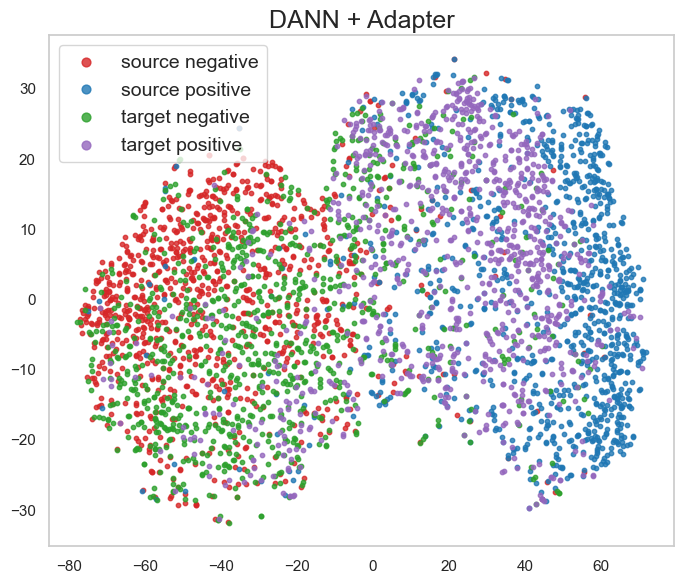

Saved DANN-only visualization to: outputs\embeddings_visualization_dann_tsne.png


In [9]:
# === Run DANN-only embedding visualization (after training) ===
from pathlib import Path


def make_labeled_loader(tokenizer, csv_path: Path, batch_size: int, max_length: int, filter_origin: Optional[str] = None):
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)
    text_col = _resolve_text_column(df)
    label_col = _resolve_label_column(df)

    if filter_origin is not None and 'origin' in df.columns:
        origin = df['origin'].astype(str).str.lower()
        df = df[origin == filter_origin.lower()]

    df = clean_dataframe(df, text_col, label_col)
    df['label_id'] = df[label_col].map(LABEL2ID)

    ds = TextDataset(
        texts=df[text_col].tolist(),
        labels=df['label_id'].tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


def limited_batches(loader, max_samples=4000):
    cnt = 0
    for batch in loader:
        bsize = batch['input_ids'].size(0)
        if cnt + bsize > max_samples:
            remain = max_samples - cnt
            if remain <= 0:
                break
            trimmed = {}
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    trimmed[k] = v[:remain]
                else:
                    trimmed[k] = v
            yield trimmed
            break
        yield batch
        cnt += bsize


def batches_iter(batches):
    for b in batches:
        yield b


device_vis = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dir = Path(CFG['output_dir']) / 'best'
model, tokenizer, _ = load_model(model_dir=model_dir, device_override=device_vis)

src_loader = make_labeled_loader(
    tokenizer=tokenizer,
    csv_path=Path(CFG['source_csv']),
    batch_size=CFG['batch_size'],
    max_length=CFG['max_length'],
)

eval_path = Path(CFG['eval_csv']) if CFG.get('eval_csv') else None
if eval_path is None or not eval_path.exists():
    raise FileNotFoundError('CFG[\'eval_csv\'] missing; provide labeled target set to visualize.')

tgt_loader = make_labeled_loader(
    tokenizer=tokenizer,
    csv_path=eval_path,
    batch_size=CFG['batch_size'],
    max_length=CFG['max_length'],
    filter_origin='target',
)

max_per_domain = 2000
src_batches = list(limited_batches(src_loader, max_samples=max_per_domain))
tgt_batches = list(limited_batches(tgt_loader, max_samples=max_per_domain))

# DANN-only stage
stage = 'encoder+domain+task'

Xs_src, Ys_src = extract_embeddings_from_dataloader(
    model,
    batches_iter(src_batches),
    device_vis,
    stage=stage,
)
Xs_tgt, Ys_tgt = extract_embeddings_from_dataloader(
    model,
    batches_iter(tgt_batches),
    device_vis,
    stage=stage,
)

X = np.concatenate([Xs_src, Xs_tgt], axis=0)
Y = np.concatenate([Ys_src, Ys_tgt], axis=0)
domains = ['source'] * Xs_src.shape[0] + ['target'] * Xs_tgt.shape[0]

method = 'tsne'
proj = project_embeddings(X, method=method, n_components=2, random_state=42)

outpath = Path(CFG['output_dir']) / f'embeddings_visualization_dann_{method}.png'
plot_single_panel(
    proj,
    Y,
    domains,
    title=f'DANN + Adapter',
    outpath=str(outpath),
    figsize=(7, 6),
)
print(f'Saved DANN-only visualization to: {outpath}')

# EDA

In [10]:
# Check class balance in source & target
source_df = pd.read_csv(CFG['source_csv'])
source_text_col = _resolve_text_column(source_df)
source_label_col = _resolve_label_column(source_df)
source_df_clean = clean_dataframe(source_df, source_text_col, source_label_col)
source_df_clean['label_id'] = source_df_clean[source_label_col].map(LABEL2ID)

print("=== SOURCE CLASS DISTRIBUTION ===")
print(source_df_clean['label_id'].value_counts().sort_index())
print(source_df_clean['label_id'].value_counts(normalize=True).sort_index())

eval_df = pd.read_csv(CFG['eval_csv'])
eval_text_col = _resolve_text_column(eval_df)
eval_label_col = _resolve_label_column(eval_df)
eval_df_clean = clean_dataframe(eval_df, eval_text_col, eval_label_col)
eval_df_clean['label_id'] = eval_df_clean[eval_label_col].map(LABEL2ID)

# Filter target only
if 'origin' in eval_df_clean.columns:
    eval_df_clean = eval_df_clean[eval_df_clean['origin'].astype(str).str.lower() == 'target']

print("\n=== TARGET EVAL CLASS DISTRIBUTION ===")
print(eval_df_clean['label_id'].value_counts().sort_index())
print(eval_df_clean['label_id'].value_counts(normalize=True).sort_index())

=== SOURCE CLASS DISTRIBUTION ===
label_id
0    3348
1    3348
Name: count, dtype: int64
label_id
0    0.5
1    0.5
Name: proportion, dtype: float64

=== TARGET EVAL CLASS DISTRIBUTION ===
label_id
0    1020
1    1022
Name: count, dtype: int64
label_id
0    0.49951
1    0.50049
Name: proportion, dtype: float64


In [11]:

# Helper: Create target eval loader independently
def make_target_eval_loader(
    tokenizer,
    eval_path: Optional[Path],
    batch_size: int,
    max_length: int,
    filter_origin: str = 'target',
) -> Tuple[Optional[DataLoader], int]:
    """
    Load labeled target eval data independently.
    
    Args:
        tokenizer: HuggingFace tokenizer
        eval_path: Path to eval CSV
        batch_size: Batch size for DataLoader
        max_length: Max sequence length
        filter_origin: Filter by 'origin' column value ('target', 'source', or None)
    
    Returns:
        (eval_loader, num_samples) or (None, 0) if eval_path doesn't exist
    """
    if eval_path is None or not eval_path.exists():
        return None, 0
    
    eval_df = pd.read_csv(eval_path)
    eval_text_col = _resolve_text_column(eval_df)
    eval_label_col = _resolve_label_column(eval_df)
    
    # Filter by origin if column exists
    if filter_origin is not None and 'origin' in eval_df.columns:
        origin = eval_df['origin'].astype(str).str.lower()
        eval_df = eval_df[origin == filter_origin.lower()]
        print(f"Filtered to {filter_origin} origin: {len(eval_df)} samples")
    
    eval_df = clean_dataframe(eval_df, eval_text_col, eval_label_col)
    eval_df['label_id'] = eval_df[eval_label_col].map(LABEL2ID)
    
    eval_ds = TextDataset(
        texts=eval_df[eval_text_col].tolist(),
        labels=eval_df['label_id'].tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )
    eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)
    
    return eval_loader, len(eval_ds)


# Create target eval loader
tokenizer_eda = AutoTokenizer.from_pretrained(CFG['model_name'])
eval_path = Path(CFG['eval_csv']) if CFG.get('target_csv') else None
target_eval_loader_eda, target_eval_samples = make_target_eval_loader(
    tokenizer=tokenizer_eda,
    eval_path=eval_path,
    batch_size=CFG['batch_size'],
    max_length=CFG['max_length'],
    filter_origin='target',
)

print(f"\n✓ Target eval loader created: {target_eval_samples} samples")
if target_eval_loader_eda:
    print(f"  Batches: {len(target_eval_loader_eda)}")

# Now check class balance in target eval
if target_eval_loader_eda is not None:
    # Collect all labels from eval loader
    all_eval_labels = []
    for batch in target_eval_loader_eda:
        all_eval_labels.extend(batch['labels'].cpu().tolist())
    
    eval_df_full = pd.DataFrame({'label_id': all_eval_labels})
    
    print("\n⚠️  TARGET EVAL CLASS IMBALANCE")
    print("Class distribution (counts):")
    print(eval_df_full['label_id'].value_counts().sort_index())
    print("\nClass distribution (%):")
    dist = eval_df_full['label_id'].value_counts(normalize=True).sort_index()
    print(dist * 100)
    
    if dist[0] > 0:
        imbalance_ratio = (dist[1] / dist[0])
        print(f"\nImbalance ratio (pos/neg): {imbalance_ratio:.2f}:1")
        print("→ Monitor recall/F1 for negative class carefully!")



✓ Target eval loader created: 2042 samples
  Batches: 64

⚠️  TARGET EVAL CLASS IMBALANCE
Class distribution (counts):
label_id
0    1020
1    1022
Name: count, dtype: int64

Class distribution (%):
label_id
0    49.951028
1    50.048972
Name: proportion, dtype: float64

Imbalance ratio (pos/neg): 1.00:1
→ Monitor recall/F1 for negative class carefully!
